# Figure 2 (expanded)

Same figure as `Fig2.ipynb`, with panel **A** rebuilt:

- Primer-covered positions are dropped everywhere (`PRIMER_BED` / `MASK_PRIMERS` in
  the constants cell). Reads there carry the primer's own sequence rather than the
  template's, so both the calls and the truth variants inside a primer are removed
  before any metric is computed.
- **A** — precision / recall / F1 per tool at each MAF threshold. Each bar is the
  **median across dataset folders**, the whiskers are the **standard error**, and the
  median is printed above. Every folder contributes one value, computed exactly the way
  the old single bar was (the samples inside that folder pooled). A faint dot per folder is drawn over the
  bars (`dot_alpha` / `dot_size` / `dot_color`, or `show_dots=False` to drop them);
  `kind='box'` / `kind='violin'` swap the bars for distribution shapes.
- **B** — a single histogram of the bronko MAF difference (bronko MAF − bowtie2 MAF)
  over **every** bronko call in the same `mr*` folders panel A is built from, pooled
  across TP/FP and across which other tools agreed. x is the MAF difference, y is the number of variants per bin, and
  the dashed line is the median.
- **C**, **D** — runtime and memory. Each tool's line is now drawn explicitly instead of
  through `sns.lineplot(hue=..., style=...)`, which on seaborn 0.13 / pandas 3 assigned the
  palette in hue-level order while iterating the data in column order, so the lines were
  swapped relative to the colour key at the top of the figure.

Then `plot_panel_a_per_folder()` repeats panel A one row per dataset folder, where each
dot is an **individual sample** inside that folder.

Panels fill in as the three `run_samples_merged.sh` jobs finish; folders with no complete
sample yet are skipped, so this can be re-run at any point.

## Imports and constants

In [2]:
import os
import sys
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.patches import Rectangle

sys.path.insert(0, "/home/Users/rdd4/bronko-test/bronko_test/scripts")
from benchmark_figures import get_columns

BASES = ['A', 'C', 'G', 'T']
MIN_AF = 0.001          # matches --min-af in run_samples_merged.sh
MAF_THRESHOLDS = [0.001, 0.005, 0.01, 0.015, 0.02, 0.05, 0.1]
TOOL_ORDER = ['bronko', 'lofreq', 'ivar']

RUN_ROOT = Path('/home/Users/rdd4/bronko-test/bronko_test/simulated_hpv_runs_expanded')
TRUTH_ROOT = Path('/dodo/rdd4/GENOMICON-Seq/bronko_simulated_data')

# Amplicon primers. Positions a primer covers are excluded from every calculation --
# set MASK_PRIMERS = False to put them back.
PRIMER_BED = Path('/dodo/rdd4/GENOMICON-Seq/input_data_ampliseq/mapping_reference/primers.bed')
MASK_PRIMERS = True

_base_palette = sns.color_palette("colorblind", n_colors=4)
TOOL_PALETTE = dict(zip(TOOL_ORDER, [_base_palette[1], _base_palette[2], _base_palette[0]]))

## Loading

One dataset folder at a time, assembled the same way as in `Fig2.ipynb`.

In [3]:
def apply_ivar_pass_filter(minor_df, ivar_tsv):
    """Drop iVar from `tools` wherever iVar itself flagged the call PASS=False."""
    ivar = pd.read_csv(ivar_tsv, delimiter='\t')
    passed = {
        (int(r.POS), r.ALT) for r in ivar.itertuples()
        if str(r.PASS).strip().upper() == 'TRUE'
        and MIN_AF <= float(r.ALT_FREQ) <= 0.5
        and '+' not in str(r.ALT) and '-' not in str(r.ALT)
    }

    def keep_tools(row):
        kept = [t for t in row['tools'].split(',')
                if t != 'ivar' or (int(row['index']), row['alt']) in passed]
        return ','.join(kept) if kept else np.nan

    minor_df = minor_df.copy()
    minor_df['tools'] = minor_df.apply(keep_tools, axis=1)
    return minor_df[minor_df['tools'].notna()]


def load_primer_positions(bed_path=PRIMER_BED, enabled=MASK_PRIMERS):
    """{chrom: set of 1-based positions covered by a primer} from a BED file.

    BED is 0-based half-open; `index` in minor_variants.tsv and `position` in the truth
    CSV are 1-based (they come from VCF/iVar POS), so a BED line `HPV16REF 62 85` masks
    positions 63..85 inclusive.
    """
    if not enabled:
        return {}
    bed = pd.read_csv(bed_path, sep='\t', header=None, comment='#', usecols=[0, 1, 2],
                      names=['chrom', 'start', 'end'])
    covered = {}
    for row in bed.itertuples():
        covered.setdefault(row.chrom, set()).update(range(row.start + 1, row.end + 1))
    return covered


PRIMER_POSITIONS = load_primer_positions()
if MASK_PRIMERS:
    print('primer mask:', {c: len(p) for c, p in PRIMER_POSITIONS.items()},
          'positions from', PRIMER_BED.name)


def drop_primer_rows(df, pos_col, chrom_col=None, covered=None):
    """Drop rows whose position sits inside a primer. Returns (df, n_dropped).

    Applied to the calls AND to the truth variants: a truth variant under a primer can
    never be observed, so leaving it in would count as a permanent false negative for
    every tool and deflate recall. Removing both keeps precision and recall on the same
    footing.
    """
    covered = PRIMER_POSITIONS if covered is None else covered
    if not covered or df.empty:
        return df, 0
    pos = pd.to_numeric(df[pos_col], errors='coerce')
    if chrom_col is not None and chrom_col in df.columns:
        hit = pd.Series(
            [c in covered and p in covered[c] if pd.notna(p) else False
             for c, p in zip(df[chrom_col], pos)],
            index=df.index)
    else:
        # truth CSV carries no contig column; these runs are single-reference
        every = set().union(*covered.values())
        hit = pos.isin(every).fillna(False)
    return df[~hit], int(hit.sum())


def alt_maf_from_bt2(row):
    """Frequency of the CALLED alt allele, measured from the bowtie2 pileup."""
    if pd.isna(row['alt']):
        return row['truth_maf']          # missed truth: nothing was called here
    depth = sum(row[f'{b}_bt2'] + row[f'{b.lower()}_bt2'] for b in BASES)
    if depth == 0:
        return np.nan
    alt = row['alt']
    return (row[f'{alt.upper()}_bt2'] + row[f'{alt.lower()}_bt2']) / depth


def load_dataset(dataset, run_root=RUN_ROOT, truth_root=TRUTH_ROOT, verbose=True):
    """Load one simulated dataset folder into (minor_all, overview_all).

    Same per-sample assembly as the original Fig2 loader, with two changes:
    samples whose files are missing are skipped (runs are added folder by folder
    as the jobs finish), and `run`/`dataset` are stamped on AFTER the outer merge
    with the truth set. In the original they were set before it, which left NaN in
    `run` on every missed-truth row -- harmless when everything is pooled, but it
    would silently drop those rows (and inflate recall) once we group by sample.

    Positions covered by an amplicon primer are dropped from both the calls and the truth
    set before they are merged (see drop_primer_rows), so nothing downstream -- metrics,
    counts, or the MAF-difference panel -- sees a primer position.
    """
    run_dir, truth_dir = Path(run_root) / dataset, Path(truth_root) / dataset
    all_overviews, all_minors, num_true_variants = [], [], 0
    n_masked_called = n_masked_truth = 0

    for sample_folder in sorted(run_dir.glob('sample_*'),
                                key=lambda p: int(p.name.split('_')[1])):
        sample_name = sample_folder.name

        overview_path = sample_folder / 'overview.tsv'
        minor_path = sample_folder / 'minor_variants.tsv'
        truth_pileup = sample_folder / 'rep1_R1_k21' / 'bt_results.tsv'
        ivar_path = sample_folder / 'rep1_R1_k21' / 'rep1_R1_ivar_ivar.tsv'
        truth_path = truth_dir / sample_name / 'HPV16REF_inserted_mutations_overview.csv'

        if not (overview_path.exists() and minor_path.exists() and truth_path.exists()
                and ivar_path.exists() and truth_pileup.exists()):
            if verbose:
                print(f"  skipping {dataset}/{sample_name}: missing files")
            continue
        # a sample still being written has the header but no data row yet
        overview_df = pd.read_csv(overview_path, delimiter='\t')
        if overview_df.empty:
            if verbose:
                print(f"  skipping {dataset}/{sample_name}: overview.tsv has no data row")
            continue

        minor_df = pd.read_csv(minor_path, delimiter='\t')
        if len(minor_df) > 0:
            minor_df = get_columns(minor_df)
            minor_df = apply_ivar_pass_filter(minor_df, ivar_path)
            minor_df, dropped = drop_primer_rows(minor_df, 'index', 'reference')
            n_masked_called += dropped
        truths = pd.read_csv(truth_path)[['position', 'Variant']]
        truths, dropped = drop_primer_rows(truths, 'position')
        n_masked_truth += dropped
        truth_pile = pd.read_csv(truth_pileup, delimiter='\t')

        truth_mafs = []
        for _, row in truths.iterrows():
            pos, alt = row['position'], row['Variant']
            try:
                site = truth_pile.loc[truth_pile['index'] == pos]
                alt_count = site[alt].iloc[0] + site[alt.lower()].iloc[0]
                depth = site[['A', 'C', 'G', 'T', 'a', 'c', 'g', 't']].sum(axis=1).iloc[0]
                maf = alt_count / depth if depth != 0 else np.nan
            except (KeyError, IndexError):
                maf = np.nan
            truth_mafs.append(maf)
        truths['truth_maf'] = truth_mafs

        # Merge instead of isin to check both position and variant
        minor_df = minor_df.merge(
            truths.assign(truth=1), how='outer',
            left_on=['index', 'alt'], right_on=['position', 'Variant'])

        minor_df['truth'] = minor_df['truth'].fillna(0).astype(int)
        minor_df['total_variants'] = len(truths)
        # One consistent MAF per row, used by BOTH precision and recall below.
        minor_df['alt_maf'] = minor_df.apply(alt_maf_from_bt2, axis=1)
        # after the merge: truth-only rows must carry the sample they belong to
        minor_df['run'] = sample_name
        minor_df['dataset'] = dataset
        overview_df['run'] = sample_name
        overview_df['dataset'] = dataset

        all_overviews.append(overview_df)
        all_minors.append(minor_df)
        num_true_variants += len(truths)

    if not all_minors:
        if verbose:
            print(f"{dataset}: no complete samples yet")
        return None, None
    if verbose:
        masked = (f", primer-masked {n_masked_called} calls / {n_masked_truth} truths"
                  if PRIMER_POSITIONS else "")
        print(f"{dataset}: {len(all_minors)} samples, {num_true_variants} true variants"
              f"{masked}")
    return (pd.concat(all_minors, ignore_index=True),
            pd.concat(all_overviews, ignore_index=True))


def discover_datasets(pattern='mr*', run_root=RUN_ROOT):
    """Dataset folders that have at least one finished sample, in sorted order."""
    return sorted(
        p.name for p in Path(run_root).glob(pattern)
        if p.is_dir() and any(p.glob('sample_*/overview.tsv')))


def load_datasets(datasets, verbose=True):
    """{dataset: minor_all} for every dataset that has usable output."""
    out = {}
    for ds in datasets:
        minor, _ = load_dataset(ds, verbose=verbose)
        if minor is not None:
            out[ds] = minor
    return out

primer mask: {'HPV16REF': 1150} positions from primers.bed


## Metrics

The precision/recall/F1 arithmetic from `Fig2.ipynb`, factored out so it can be applied to a whole folder (one dot in the main figure) or to a single sample (one dot in the per-folder rows).

In [4]:
def compute_metrics(minor_counts_truth, maf_thresholds=MAF_THRESHOLDS, tool_order=TOOL_ORDER):
    """Precision / recall / F1 per tool at each MAF threshold, for one set of rows.

    Same arithmetic as plot_precision_recall_f1_vs_maf() in Fig2, factored out so it can
    be applied to any subset -- a whole dataset folder, or a single sample.

    Degenerate cases (they are common at the high thresholds, where a folder or sample
    can hold only a handful of truth variants):

    - a tool that called NOTHING above the threshold has precision 0/0. It is scored 1:
      it produced no false positive, so there is nothing to penalise on the precision
      axis. Its recall is 0, giving F1 = 0.
    - a tool that called something but got all of it wrong has precision 0 and recall 0,
      so F1's denominator is 0. It is scored 0 rather than left undefined.

    Both cases therefore stay in the figure as a real 0 on recall and F1 instead of
    dropping out of the median. The only rows still missing are thresholds a unit has no
    truth variant above at all, where recall has no denominator -- those are skipped.
    """
    rows = []
    for maf in maf_thresholds:
        # Ground-truth variants whose called-alt MAF clears the threshold.
        df_recall = minor_counts_truth[
            (minor_counts_truth['truth'] == 1) & (minor_counts_truth['alt_maf'] > maf)
        ][['tools', 'truth', 'alt_maf']]
        if df_recall.empty:
            continue
        total_truths = len(df_recall)
        exploded = df_recall.assign(tool=df_recall['tools'].str.split(',')).explode('tool')
        tp = (exploded.groupby('tool').size()
              .reindex(tool_order, fill_value=0).astype(float))

        # Called variants, thresholded on the SAME quantity as recall so both share an x-axis.
        df_prec = minor_counts_truth[
            minor_counts_truth['tools'].notna() & (minor_counts_truth['alt_maf'] > maf)
        ][['tools', 'truth']]
        exploded = df_prec.assign(tool=df_prec['tools'].str.split(',')).explode('tool')
        called = exploded.groupby('tool').size().reindex(tool_order, fill_value=0).astype(float)
        true_pos = (exploded[exploded['truth'] == 1].groupby('tool').size()
                    .reindex(tool_order, fill_value=0).astype(float))

        for tool in tool_order:
            recall = tp[tool] / total_truths
            # 0/0 -> 1.0: no calls means no false positives
            precision = true_pos[tool] / called[tool] if called[tool] > 0 else 1.0
            denom = precision + recall
            # denom == 0 only when the tool called something and got all of it wrong
            f1 = 2 * precision * recall / denom if denom > 0 else 0.0
            rows.append(dict(tool=tool, MAF=maf, Precision=precision, Recall=recall, F1=f1,
                             n_truths=total_truths, n_called=int(called[tool])))
    return pd.DataFrame(rows)


def metrics_by_dataset(minors, **kw):
    """One row per (dataset, tool, MAF): the 10 samples in a folder pooled, as in Fig2."""
    return pd.concat(
        [compute_metrics(m, **kw).assign(unit=ds) for ds, m in minors.items()],
        ignore_index=True)


def metrics_by_sample(minor, **kw):
    """One row per (sample, tool, MAF) inside a single dataset folder."""
    return pd.concat(
        [compute_metrics(g, **kw).assign(unit=run) for run, g in minor.groupby('run')],
        ignore_index=True)

## Variant counts

The raw counts behind panel A -- how many truth variants and how many false (non-truth)
called sites survive each MAF threshold, how many samples still carry a variant there, and
TP / FP / FN per tool. Same thresholding as `compute_metrics()` above, so
`TP/(TP+FP)` and `TP/(TP+FN)` are exactly the Precision and Recall that panel A plots.

In [5]:
def _sample_key(minor):
    """Unique id per sample. `run` is only sample_N, so it repeats across folders."""
    if 'dataset' in minor.columns:
        return minor['dataset'].astype(str) + '/' + minor['run'].astype(str)
    return minor['run'].astype(str)


def compute_counts(minor, maf_thresholds=MAF_THRESHOLDS, tool_order=TOOL_ORDER):
    """Raw variant counts behind the panel A metrics, one row per (MAF, tool).

    Thresholding is the same as compute_metrics(): a row counts at a threshold when its
    alt_maf -- the called allele's frequency in the bowtie2 pileup, or the truth MAF for a
    truth variant nobody called -- is strictly above it, so TP/(TP+FP) and TP/(TP+FN)
    reproduce the Precision and Recall plotted in panel A exactly.

    Per (MAF, tool):  TP  called by this tool and in the truth set
                      FP  called by this tool and not in the truth set
                      FN  truth variants above the threshold this tool did not call
    Repeated on every tool row of a threshold (they describe the threshold, not the tool):
                      n_truth          ground-truth variants above the threshold
                      n_false          distinct called sites above it that are not truth,
                                       counted once even when several tools called them
                      n_samples_truth  samples with >0 truth variants above the threshold
                      n_samples_called samples with >0 calls (any tool) above it
                      n_samples        samples in the input, for reference
    """
    minor = minor.assign(_sample=_sample_key(minor))
    n_samples = minor['_sample'].nunique()
    rows = []

    for maf in maf_thresholds:
        above = minor[minor['alt_maf'] > maf]
        truths = above[above['truth'] == 1]
        called = above[above['tools'].notna()]
        false_sites = called[called['truth'] == 0]

        n_truth = len(truths)
        shared = dict(
            n_truth=n_truth,
            n_false=len(false_sites),
            n_samples_truth=truths['_sample'].nunique(),
            n_samples_called=called['_sample'].nunique(),
            n_samples=n_samples,
        )

        exploded = called.assign(tool=called['tools'].str.split(',')).explode('tool')
        by_tool = exploded.groupby(['tool', 'truth']).size().unstack(fill_value=0)
        tp = by_tool.get(1, pd.Series(dtype=int)).reindex(tool_order, fill_value=0)
        fp = by_tool.get(0, pd.Series(dtype=int)).reindex(tool_order, fill_value=0)

        for tool in tool_order:
            tp_t, fp_t = int(tp[tool]), int(fp[tool])
            fn_t = n_truth - tp_t
            # same degenerate-case handling as compute_metrics(), so the tables and the
            # panel A bars still agree: no calls -> precision 1, all-wrong calls -> F1 0
            precision = tp_t / (tp_t + fp_t) if (tp_t + fp_t) else 1.0
            if n_truth:
                recall = tp_t / n_truth
                denom = precision + recall
                f1 = 2 * precision * recall / denom if denom > 0 else 0.0
            else:
                # no truth variant above the threshold: recall has no denominator, and
                # compute_metrics() skips the row outright
                recall = f1 = np.nan
            rows.append(dict(MAF=maf, tool=tool, TP=tp_t, FP=fp_t, FN=fn_t,
                             Precision=precision, Recall=recall, F1=f1, **shared))

    return pd.DataFrame(rows)


def counts_pooled(minors, **kw):
    """One table over every sample in every folder -- counts add, so pooling is a sum."""
    return compute_counts(pd.concat(minors.values(), ignore_index=True), **kw)


def counts_by_dataset(minors, **kw):
    """One block of counts per dataset folder, stacked, with the folder in `unit`."""
    return pd.concat([compute_counts(m, **kw).assign(unit=ds) for ds, m in minors.items()],
                     ignore_index=True)


def counts_by_sample(minor, **kw):
    """One block of counts per sample inside a single dataset folder."""
    return pd.concat([compute_counts(g, **kw).assign(unit=run)
                      for run, g in minor.groupby('run')], ignore_index=True)


THRESHOLD_COLS = ['n_truth', 'n_false', 'n_samples_truth', 'n_samples_called', 'n_samples']
TOOL_COLS = ['TP', 'FP', 'FN', 'Precision', 'Recall', 'F1']


def show_count_tables(counts, tool_order=TOOL_ORDER, digits=3):
    """Print one table per MAF threshold: the threshold's totals, then a row per tool."""
    from IPython.display import display

    for maf, block in counts.groupby('MAF'):
        totals = block[THRESHOLD_COLS].iloc[0]
        print(f"\nMAF > {maf}\n"
              f"  truth variants: {totals['n_truth']:,}   "
              f"false (non-truth) called sites: {totals['n_false']:,}\n"
              f"  samples with >0 truth variants: {totals['n_samples_truth']} / {totals['n_samples']}"
              f"   with >0 calls: {totals['n_samples_called']} / {totals['n_samples']}")
        tbl = (block.set_index('tool').reindex(tool_order)[TOOL_COLS]
               .round(digits).rename_axis(None))
        display(tbl)


def count_table_wide(counts, tool_order=TOOL_ORDER, metrics=('TP', 'FP', 'FN')):
    """Every threshold in one frame: threshold totals, then TP/FP/FN per tool as columns.

    Columns are flattened to 'bronko TP' rather than left as a MultiIndex, so the table
    stays readable printed and goes straight to CSV.
    """
    totals = counts.groupby('MAF')[THRESHOLD_COLS].first()
    per_tool = (counts.pivot(index='MAF', columns='tool', values=list(metrics))
                .reindex(columns=pd.MultiIndex.from_product([list(metrics), tool_order])))
    per_tool.columns = [f'{tool} {metric}' for metric, tool in per_tool.columns]
    per_tool = per_tool[[f'{tool} {metric}' for tool in tool_order for metric in metrics]]
    return totals.join(per_tool)

## Panel A

In [6]:
def plot_precision_recall_f1(metrics, axes, maf_thresholds=MAF_THRESHOLDS,
                             tool_order=TOOL_ORDER, kind='bar', show_dots=True,
                             show_values=True, dot_size=2.5, dot_alpha=0.45,
                             dot_color='0.15', values_above='error', value_fmt='{:.2f}',
                             legend=False, ylim=(0, 1.18), bold=False,
                             titles=('iSNV Precision', 'iSNV Recall', 'iSNV F1 Score')):
    """Panel A: precision / recall / F1 per tool at each MAF threshold.

    `metrics` is tidy output from metrics_by_dataset (one unit = one dataset folder) or
    metrics_by_sample (one unit = one sample), with columns unit, tool, MAF, and the
    three metric columns.

    kind='bar'    bar at the MEDIAN across units, whiskers = standard error
                  (std/sqrt(n), ddof=1 -- seaborn's errorbar='se'), value printed above.
                  Note the pairing is the one asked for, not the textbook one: the
                  standard error describes the spread of the MEAN, so on a skewed
                  metric the whiskers are not centred on the bar they sit on.
    kind='box'    box of the distribution (no error bars, no value labels)
    kind='violin' violin of the distribution

    show_dots overlays one dot per unit, faint by default (dot_alpha / dot_size /
    dot_color) so the bars stay the thing you read first.

    values_above='error' puts each value just above its error bar, so the number stays
    attached to its own bar; ='dots' clears the highest dot instead, which reads better
    with solid dots but can float a label far above a low bar.

    Font sizes are left to rcParams so the style block in the figure cell governs them;
    only bold is set here, which no rcParam covers.
    """
    metrics = metrics[metrics['MAF'].isin(maf_thresholds)].copy()
    metrics['MAF'] = pd.Categorical(metrics['MAF'], categories=maf_thresholds, ordered=True)

    for ax, metric, title in zip(axes, ('Precision', 'Recall', 'F1'), titles):
        data = metrics.dropna(subset=[metric])

        if kind == 'bar':
            sns.barplot(data=data, x='MAF', y=metric, hue='tool', hue_order=tool_order,
                        palette=TOOL_PALETTE, ax=ax, estimator='median', errorbar='se',
                        capsize=0.12, err_kws={'linewidth': 0.9}, legend=False)
            
            for container in ax.containers:
                for bar in container:
                    bar.set_alpha(0.5)
                    bar.set_edgecolor('0.15')
                    bar.set_linewidth(0.8)
        elif kind == 'violin':
            sns.violinplot(data=data, x='MAF', y=metric, hue='tool', hue_order=tool_order,
                           palette=TOOL_PALETTE, ax=ax, width=0.7, linewidth=0.9,
                           legend=False)
        else:
            sns.boxplot(data=data, x='MAF', y=metric, hue='tool', hue_order=tool_order,
                        palette=TOOL_PALETTE, ax=ax, showfliers=False, width=0.7,
                        linewidth=0.9, fliersize=0, legend=False)
            
            for patch in ax.patches:
                patch.set_alpha(0.7)
                patch.set_edgecolor('0.15')
                patch.set_linewidth(0.8)

        if show_dots:
            # one dot per unit, kept faint so it reads as texture over the bar
            sns.stripplot(data=data, x='MAF', y=metric, hue='tool', hue_order=tool_order,
                          dodge=True, jitter=0.12, size=dot_size, alpha=dot_alpha,
                          linewidth=0, palette=TOOL_PALETTE,
                          ax=ax, legend=False)

        if kind == 'bar' and show_values:
            _label_bars(ax, data, metric, maf_thresholds, tool_order, value_fmt=value_fmt,
                        over_dots=(show_dots and values_above == 'dots'))
        if bold:
            ax.set_title(title, fontweight='bold')
            ax.set_ylabel(metric, fontweight='bold')
            ax.set_xlabel('MAF Threshold', fontweight='bold')
        else:
            ax.set_title(title)
            ax.set_ylabel(metric)
            ax.set_xlabel('MAF Threshold')
        ax.set_ylim(*ylim)

        ax.set_xticks(range(len(maf_thresholds)))
        ax.set_xticklabels([f"{m*100}%" for m in maf_thresholds])
        if legend and ax is axes[0]:
            ax.legend(*tool_handles(tool_order), frameon=False, loc='lower left')
    return metrics


def _label_bars(ax, data, metric, maf_thresholds, tool_order, value_fmt='{:.2f}',
                over_dots=True):
    """Print each bar's median above it, clear of its error bar (and of the dots).

    Placed per bar rather than with ax.bar_label(padding=...), which takes one padding
    for every bar and so collides with the taller error bars.
    """
    stats = (data.groupby(['MAF', 'tool'], observed=False)[metric]
             .agg(median='median',
                  sem=lambda s: s.std(ddof=1) / np.sqrt(len(s)) if len(s) > 1 else 0.0,
                  top='max'))
    # containers come back in hue_order, bars within one in x-category order
    for container, tool in zip(ax.containers, tool_order):
        for bar, maf in zip(container, maf_thresholds):
            if (maf, tool) not in stats.index:
                continue
            row = stats.loc[(maf, tool)]
            if pd.isna(row['median']):
                continue
            y = row['median'] + (0.0 if pd.isna(row['sem']) else row['sem'])
            if over_dots:
                y = max(y, row['top'])
            ax.annotate(value_fmt.format(row['median']),
                        xy=(bar.get_x() + bar.get_width() / 2, y),
                        xytext=(0, 2), textcoords='offset points',
                        ha='center', va='bottom', fontweight='bold', zorder=6,
                        fontsize=plt.rcParams['font.size'] * 0.85)


def tool_handles(tool_order=TOOL_ORDER):
    """(handles, labels) for a tool colour key, matching the boxes."""
    return ([Rectangle((0, 0), 1, 1, facecolor=TOOL_PALETTE[t], edgecolor='k', lw=0.5)
             for t in tool_order], list(tool_order))

## Panels B / C / D

B is the pooled MAF-difference distribution; C and D are as in `Fig2.ipynb`, with the tool/colour mix-up in the line plots fixed.

In [7]:
def plot_bronko_maf_diff(ax, bronko_vars, bins=100, xlim=None, color=None,
                         show_stats=False, bold=False):
    """Panel B: one histogram of the bronko MAF error over every bronko call.
    """
    diff = (bronko_vars['bronko_maf'] - bronko_vars['bt2_maf']).dropna()
    color = color or TOOL_PALETTE['bronko']

    if xlim is None:
        span = float(diff.abs().max()) if len(diff) else 1e-3
        span = span if span > 0 else 1e-3
        xlim = (-span * 1.05, span * 1.05)

    sns.histplot(x=diff, bins=bins, binrange=xlim, stat='count', element='step',
                 color=color, alpha=0.45, linewidth=0.8, ax=ax)

    ax.axvline(0, color='black', alpha=0.6, linestyle=':', linewidth=1)
    ax.axvline(diff.median(), color='black', alpha=0.9, linestyle='--', linewidth=1)

    if show_stats:
        n_out = int(((diff < xlim[0]) | (diff > xlim[1])).sum())
        stats = (f"n = {len(diff)}\nmedian = {diff.median():.2e}\n"
                 f"IQR = {diff.quantile(.25):.2e} to {diff.quantile(.75):.2e}")
        if n_out:
            stats += f"\n{n_out} outside range"
        ax.text(0.02, 0.97, stats, transform=ax.transAxes, ha='left', va='top',
                fontsize=8)

    ax.set_xlim(*xlim)
    # plain decimals on the ticks: no 10^-2 multiplier parked in the corner, so the number
    # under a tick is the MAF difference itself. ScalarFormatter picks the number of
    # decimals from the tick spacing, so a zoomed-in xlim still gets enough digits.
    ax.xaxis.set_major_locator(mpl.ticker.MaxNLocator(10, symmetric=True))
    tick_fmt = mpl.ticker.ScalarFormatter(useOffset=False)
    tick_fmt.set_scientific(False)
    ax.xaxis.set_major_formatter(tick_fmt)
    # ax.set_xscale("symlog", linthresh=1e-2)
    ax.set_yscale("symlog", linthresh=10)
    if bold:
        ax.set_xlabel("bronko MAF - bowtie2 MAF", fontweight='bold')
        ax.set_ylabel("Number of variants", fontweight='bold')
        ax.set_title("MAF estimate differences", fontweight='bold')
    else:
        ax.set_xlabel("bronko MAF - bowtie2 MAF")
        ax.set_ylabel("Number of variants")
        ax.set_title("MAF estimate differences")
    ax.tick_params(axis='both')


def bronko_calls(minors):
    """Every call that includes bronko, over one folder or a whole {dataset: minor} dict.

    Truth variants nobody called have `tools` NaN and are dropped -- there is no bronko
    MAF to difference on those rows.
    """
    frame = (pd.concat(minors.values(), ignore_index=True)
             if isinstance(minors, dict) else minors)
    return frame[frame['tools'].notna() & frame['tools'].str.contains('bronko')]


# markers keyed by tool, so the runtime and memory panels mark the same tool the same way
TOOL_MARKERS = {"bowtie2 (no variant calling)": "o", "samtools": "X", "bronko": "s",
                "lofreq": "^", "ivar": "D"}


def _load_resource_table(folder_list, col_to_tool, pre):
    """One row per folder, one column per tool, in folder_list order (missing ones skipped)."""
    rows = []
    for folder in folder_list:
        path = os.path.join(pre, folder, "sample_1/overview.tsv")
        if not os.path.exists(path):
            continue
        df = pd.read_csv(path, sep="\t")
        entry = {"folder": folder}
        for col, tool in col_to_tool.items():
            entry[tool] = pd.to_numeric(df.get(col, pd.Series([pd.NA])).iloc[0], errors="coerce")
        rows.append(entry)
    return pd.DataFrame(rows)


def _plot_resource_lines(table, tool_order, palette, ax, xticklabels=None):
    """One line per tool, drawn explicitly in tool_order.

    Deliberately not sns.lineplot: with hue= and style= both set, seaborn 0.13 hands the
    colours out in hue-level order while it walks the data in appearance order, so every
    line ended up wearing another tool's colour (bronko drawn with LoFreq's timings, and
    so on). Plotting per tool keeps colour, marker and data tied to the same tool.

    Tick labels come from the folder names ('100k_reads' -> '100k') rather than a fixed
    list, so they stay aligned when a folder has no output yet.
    """
    x = np.arange(len(table))
    for tool in tool_order:
        if tool not in table.columns:
            continue
        ax.plot(x, table[tool].astype(float), color=palette[tool],
                marker=TOOL_MARKERS.get(tool, 'o'), linewidth=3, markersize=8, label=tool)
    ax.set_xticks(x)
    ax.set_xticklabels(xticklabels if xticklabels is not None
                       else [str(f).split('_')[0] for f in table['folder']])


def plot_times_across_folders(folder_list, ax, xticklabels=None, bold=False,
                              pre="/home/Users/rdd4/bronko-test/bronko_test/simulated_hpv_runs"):
    col_to_tool = {"BT2_Time": "bowtie2 (no variant calling)", "BT2_LoFreq_Time": "lofreq",
                   "BT2_iVar_Time": "ivar", "Bronko_Time": "bronko"}
    tool_order = ["bowtie2 (no variant calling)", "bronko", "lofreq", "ivar"]
    base_palette = sns.color_palette("colorblind", n_colors=4)
    palette = dict(zip(tool_order, ["gray", base_palette[1], base_palette[2], base_palette[0]]))

    table = _load_resource_table(folder_list, col_to_tool, pre)
    if table.empty:
        return

    _plot_resource_lines(table, tool_order, palette, ax, xticklabels)
    if bold:
        ax.set_title("Runtime Across Datasets", fontweight="bold")
        ax.set_xlabel("Number of Reads", fontweight="bold")
        ax.set_ylabel("Runtime (s)", fontweight="bold")
    else:
        ax.set_title("Runtime Across Datasets")
        ax.set_xlabel("Number of Reads")
        ax.set_ylabel("Runtime (s)")
    ax.set_yscale("log")
    ax.set_ylim(1, 10000)


def plot_memory_across_folders(folder_list, ax, xticklabels=None, bold=False,
                               pre="/home/Users/rdd4/bronko-test/bronko_test/simulated_hpv_runs"):
    col_to_tool = {"BT2_Mem": "bowtie2 (no variant calling)", "Samtools_Mem": "samtools",
                   "BT2_LoFreq_Mem": "lofreq", "BT2_iVar_Mem": "ivar", "Bronko_Mem": "bronko"}
    tool_order = ["bowtie2 (no variant calling)", "samtools", "bronko", "lofreq", "ivar"]
    base_palette = sns.color_palette("colorblind", n_colors=4)
    palette = dict(zip(tool_order, ["gray", "black", base_palette[1], base_palette[2],
                                    base_palette[0]]))

    table = _load_resource_table(folder_list, col_to_tool, pre)
    if table.empty:
        return

    _plot_resource_lines(table, tool_order, palette, ax, xticklabels)
    if bold:
        ax.set_title("Memory Usage Across Datasets", fontweight="bold")
        ax.set_xlabel("Number of Reads", fontweight="bold")
        ax.set_ylabel("Memory (MB)", fontweight="bold")
    else:
        ax.set_title("Memory Usage Across Datasets")
        ax.set_xlabel("Number of Reads")
        ax.set_ylabel("Memory (MB)")
    ax.set_yscale("log")


## Load the data

`mr1e-*` folders drive panels A and B. `baseline_mut_5e5` is still loaded below but no
longer feeds the figure.

In [8]:
# panel A: every mr1e-4_* / mr1e-5_* folder that has finished samples
mr1e_datasets = [d for d in discover_datasets('mr*')]
print('folders with output:', len(mr1e_datasets))

mr1e_minors = load_datasets(mr1e_datasets)
folder_metrics = metrics_by_dataset(mr1e_minors)

# a tool that called nothing above a threshold scores precision 1 (it produced no false
# positive) and F1 0, so the cell stays in the bars instead of dropping out
n_cells = len(folder_metrics)
no_calls = int((folder_metrics['n_called'] == 0).sum())
zero_f1 = int((folder_metrics['F1'] == 0).sum())
print(f'{n_cells} (folder, tool, threshold) cells, {no_calls} with no calls at all, '
      f'{zero_f1} scoring F1 = 0')
folder_metrics

folders with output: 81
mr1e-4_c10000_cy15: 10 samples, 42808 true variants, primer-masked 188 calls / 7262 truths
mr1e-4_c10000_cy15_100k: 10 samples, 42696 true variants, primer-masked 277 calls / 7340 truths
mr1e-4_c10000_cy15_1m: 10 samples, 42573 true variants, primer-masked 207 calls / 7324 truths
mr1e-4_c10000_cy25: 10 samples, 42681 true variants, primer-masked 237 calls / 7286 truths
mr1e-4_c10000_cy25_100k: 10 samples, 42607 true variants, primer-masked 284 calls / 7312 truths
mr1e-4_c10000_cy25_1m: 10 samples, 42707 true variants, primer-masked 230 calls / 7325 truths
mr1e-4_c10000_cy35: 10 samples, 42851 true variants, primer-masked 224 calls / 7231 truths
mr1e-4_c10000_cy35_100k: 10 samples, 42695 true variants, primer-masked 316 calls / 7266 truths
mr1e-4_c10000_cy35_1m: 10 samples, 42868 true variants, primer-masked 215 calls / 7210 truths
mr1e-4_c1000_cy15: 10 samples, 6496 true variants, primer-masked 93 calls / 1053 truths
mr1e-4_c1000_cy15_100k: 10 samples, 6383 true

,tool,MAF,Precision,Recall,F1,n_truths,n_called,unit
0,bronko,0.001,0.996491,0.012896,0.025463,22022,285,mr1e-4_c10000_cy15
1,lofreq,0.001,0.946309,0.012805,0.025269,22022,298,mr1e-4_c10000_cy15
2,ivar,0.001,0.732773,0.059395,0.109884,22022,1785,mr1e-4_c10000_cy15
3,bronko,0.005,0.996416,0.248436,0.397711,1119,279,mr1e-4_c10000_cy15
4,lofreq,0.005,0.965909,0.227882,0.368764,1119,264,mr1e-4_c10000_cy15
...,...,...,...,...,...,...,...,...
1504,lofreq,0.050,0.833333,0.156250,0.263158,32,6,mr5e-5_c500_cy35_1m
1505,ivar,0.050,0.507937,1.000000,0.673684,32,63,mr5e-5_c500_cy35_1m
1506,bronko,0.100,1.000000,0.777778,0.875000,9,7,mr5e-5_c500_cy35_1m
1507,lofreq,0.100,1.000000,0.444444,0.615385,9,4,mr5e-5_c500_cy35_1m


## Figure 2

Panel A is the new box + dots; B, C and D are as they were.

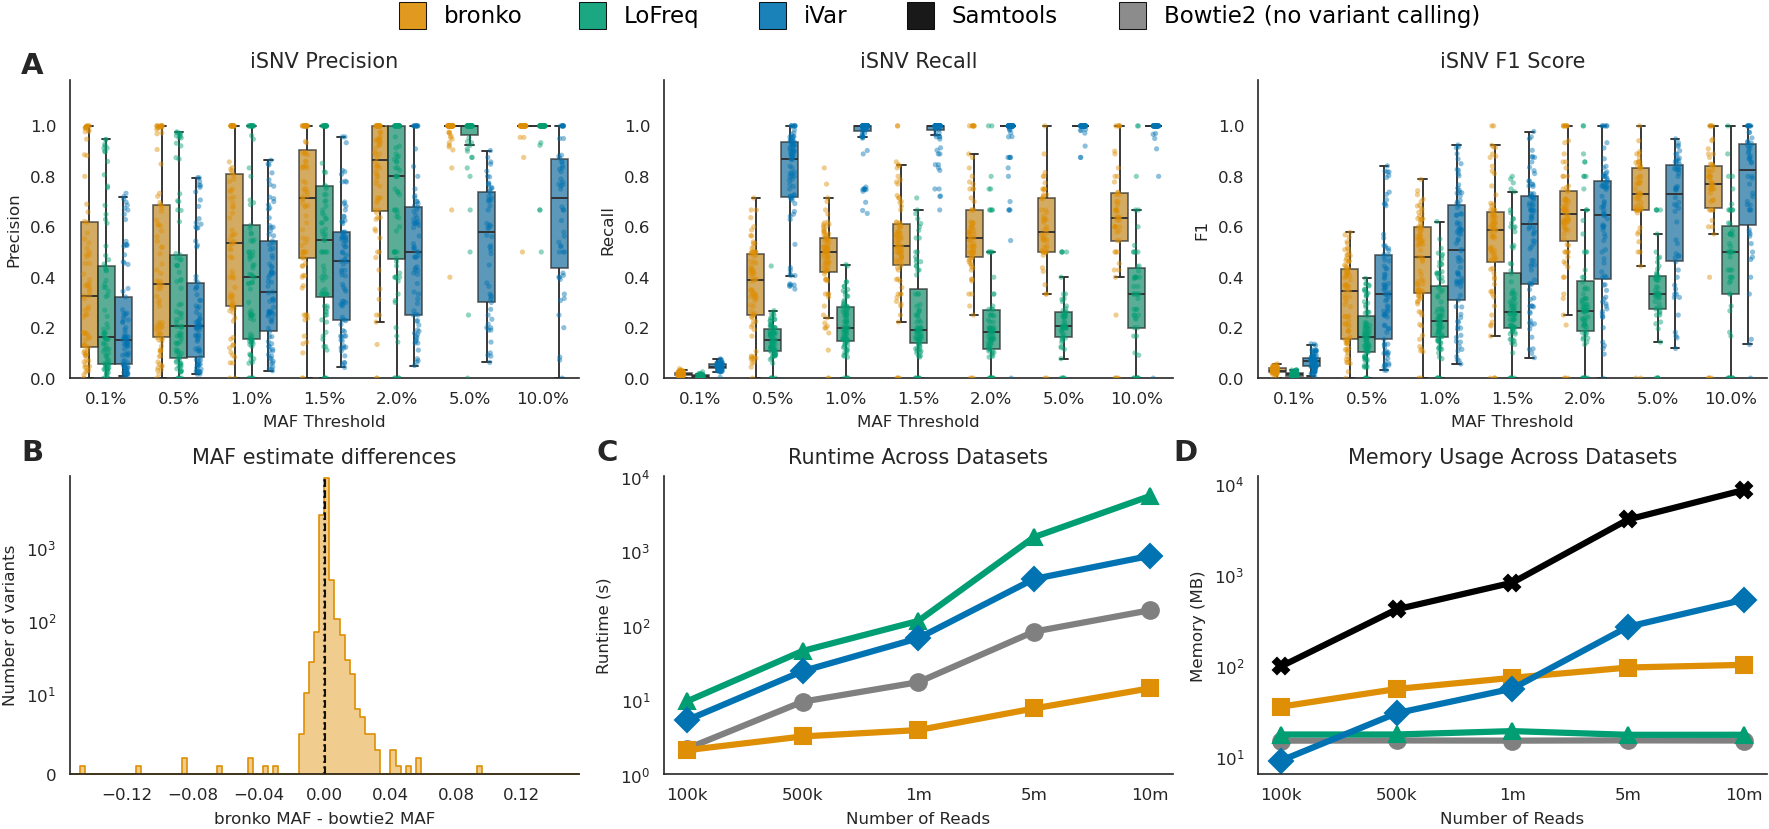

In [9]:
import matplotlib as mpl

sns.set_theme(style="white")

# style block first: axes.spines.* and the figure-level keys are read when the figure and
# its axes are created, so setting them after plt.subplots() left the spines untouched
mpl.rcParams.update({
    # Fonts
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],

    # Editable fonts in PDF/PS
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",

    # Font sizes (8-10 pt)
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,

    # Axes
    "axes.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 3,
    "ytick.major.size": 3,

    # Lines
    "lines.linewidth": 1.5,
    "lines.markersize": 5,

    # Save figures
    "savefig.dpi": 600,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,

    # Figure defaults
    "figure.dpi": 150,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})

fig, axes = plt.subplots(2, 3, figsize=(12, 6))

# top row (A): bar = median across the mr* folders, whiskers = standard error, value on
# top, plus a faint dot per folder. dot_alpha / dot_size / dot_color tune how faint.
plot_precision_recall_f1(folder_metrics, axes[0], kind='box', show_dots=True,
                         dot_size=2.5, dot_alpha=0.45)

# bottom row: MAF-difference distribution, runtime, memory
bronko_vars = bronko_calls(mr1e_minors)
plot_bronko_maf_diff(axes[1, 0], bronko_vars)
plot_times_across_folders(['100k_reads', '500k_reads', '1m_reads', '5m_reads', '10m_reads'],
                          axes[1, 1])
plot_memory_across_folders(['100k_reads_mem', '500k_reads_mem', '1m_reads_mem',
                            '5m_reads_mem', '10m_reads_mem'], axes[1, 2])

labels = ["bronko", "LoFreq", "iVar", "Samtools", "Bowtie2 (no variant calling)"]

# Same colors as runtime plot
base_palette = sns.color_palette("colorblind", n_colors=4)
colors = [base_palette[1], base_palette[2], base_palette[0], "black", "gray"]

y = 0.92           # vertical position in figure coords
x_start = 0.23     # where first label starts
box_w, box_h = 0.015, 0.03

for i, (label, color) in enumerate(zip(labels, colors)):
    x_step = 0.094 if i == 3 else 0.1
    x = x_start + i * x_step
    fig.patches.append(Rectangle(
        (x, y - box_h / 2), box_w, box_h, transform=fig.transFigure,
        facecolor=color, edgecolor='black', lw=0.5, alpha=0.9))
    fig.text(x + box_w + 0.01, y, label, ha='left', va='center',
             fontsize=11, color='black')

fig.text(0.02, 0.88, 'A', fontsize=14, fontweight='bold', ha='left', va='top')
fig.text(0.02, 0.45, 'B', fontsize=14, fontweight='bold', ha='left', va='top')
fig.text(0.34, 0.45, 'C', fontsize=14, fontweight='bold', ha='left', va='top')
fig.text(0.66, 0.45, 'D', fontsize=14, fontweight='bold', ha='left', va='top')
plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=colors)
plt.savefig("../figures/Fig2_expanded.pdf", bbox_inches="tight", dpi=600)
plt.savefig("../figures/Fig2_expanded.svg", bbox_inches="tight", dpi=600)
plt.savefig("../figures/Fig2_expanded.png", bbox_inches="tight", dpi=600)
plt.show()

In [10]:
folder_metrics.to_csv("../Fig2_expanded_folder_metrics_ivar_true_with_primers.csv", index=False)

In [11]:
combined_df = pd.concat(
    [df.assign(sample=sample) for sample, df in mr1e_minors.items()],
    ignore_index=True
)
combined_df.to_csv("minor_calls_ivar_true_with_primers.csv", index=False)

## Panel A per folder

One row per dataset folder, one dot per sample inside it.

In [12]:
def plot_panel_a_per_folder(minors, outstem=None, dot_size=3, dot_alpha=0.7,
                            dot_color='k', values_above='dots', figures_dir='../figures',
                            row_height=3.1, sharex=True, kind='bar', show_dots=True,
                            show_values=True):
    """Panel A repeated one row per dataset folder, each dot an individual sample.

    `minors` is {dataset: minor_all} from load_datasets(). Rows keep the order of the
    dict, so pass it already sorted the way you want the figure stacked.
    """
    datasets = list(minors)
    if not datasets:
        print('nothing to plot')
        return None, None

    fig, axes = plt.subplots(len(datasets), 3,
                             figsize=(12, row_height * len(datasets)),
                             squeeze=False, sharex=sharex, sharey=True)
    all_metrics = []
    for ri, ds in enumerate(datasets):
        m = metrics_by_sample(minors[ds])
        all_metrics.append(m.assign(dataset=ds))
        # these rows exist to show the individual runs, so their dots stay solid
        plot_precision_recall_f1(m, axes[ri], dot_size=dot_size, dot_alpha=dot_alpha,
                                 dot_color=dot_color, values_above=values_above,
                                 kind=kind, show_dots=show_dots, show_values=show_values,
                                 titles=('iSNV Precision', 'iSNV Recall', 'iSNV F1 Score')
                                 if ri == 0 else ('', '', ''))
        # the row is one dataset across all three metrics, so the row label names the
        # dataset only -- the column titles on row 0 say which metric is which
        n = m['unit'].nunique()
        axes[ri][0].set_ylabel(f'{ds}\n(n={n} samples)', fontweight='bold')
        for ax in axes[ri][1:]:
            ax.set_ylabel('')
        if ri != len(datasets) - 1:
            for ax in axes[ri]:
                ax.set_xlabel('')

    fig.tight_layout(rect=[0, 0, 1, 1 - 0.35 / (row_height * len(datasets))])
    fig.legend(*tool_handles(), loc='upper center', ncol=3, frameon=False, fontsize=10,
               bbox_to_anchor=(0.5, 1.0))
    if outstem:
        for ext in ('png', 'pdf', 'svg'):
            fig.savefig(f'{figures_dir}/{outstem}.{ext}', bbox_inches='tight', dpi=300,
                        facecolor='white')
    return fig, pd.concat(all_metrics, ignore_index=True)

In [13]:
# every folder with output, not just mr1e -- one row each
all_datasets = discover_datasets('mr*')
print(f'{len(all_datasets)} folders with output')

all_minors = load_datasets(all_datasets, verbose=False)
fig_rows, per_sample_metrics = plot_panel_a_per_folder(
    all_minors, outstem='Fig2A_per_folder')
plt.show()

81 folders with output


KeyboardInterrupt: 

Error in callback <function flush_figures at 0x7f7fd5460510> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

In [ ]:
# the numbers behind the rows, in case you want them as a table
per_sample_metrics.head(21)

,tool,MAF,Precision,Recall,F1,n_truths,n_called,unit,dataset
0,bronko,0.001,1.000000,0.017426,0.034255,2525,44,sample_1,mr1e-4_c10000_cy15
1,lofreq,0.001,0.916667,0.013069,0.025771,2525,36,sample_1,mr1e-4_c10000_cy15
2,ivar,0.001,0.718750,0.054653,0.101583,2525,192,sample_1,mr1e-4_c10000_cy15
3,bronko,0.005,1.000000,0.380531,0.551282,113,43,sample_1,mr1e-4_c10000_cy15
4,lofreq,0.005,0.966667,0.256637,0.405594,113,30,sample_1,mr1e-4_c10000_cy15
5,ivar,0.005,0.769841,0.858407,0.811715,113,126,sample_1,mr1e-4_c10000_cy15
6,bronko,0.010,1.000000,0.750000,0.857143,20,15,sample_1,mr1e-4_c10000_cy15
7,lofreq,0.010,1.000000,0.400000,0.571429,20,8,sample_1,mr1e-4_c10000_cy15
8,ivar,0.010,0.950000,0.950000,0.950000,20,20,sample_1,mr1e-4_c10000_cy15
9,bronko,0.015,1.000000,0.833333,0.909091,6,5,sample_1,mr1e-4_c10000_cy15


## Count tables per MAF threshold

Pooled over every sample in every `mr*` folder -- the same rows that feed panel A, but
counted rather than averaged. Note this is a **pooled** precision/recall, so it will not
equal the bar in panel A: that bar is the median over folders, and the big folders
(`c10000`, where a sample has thousands of truth variants) dominate a pooled ratio.

`n_false` counts a non-truth site once even if two tools called it, so it is a property of
the threshold, not a per-tool FP total -- the per-tool FPs are in the tables below it and
sum to more.

In [ ]:
# pooled over every mr* folder loaded above
pooled_counts = counts_pooled(mr1e_minors)
show_count_tables(pooled_counts)

# all four thresholds side by side
count_table_wide(pooled_counts)


MAF > 0.001
  truth variants: 459,721   false (non-truth) called sites: 47,299
  samples with >0 truth variants: 798 / 798   with >0 calls: 798 / 798


,TP,FP,FN,Precision,Recall,F1
bronko,7384,5888,452337,0.556,0.016,0.031
lofreq,4918,6247,454803,0.440,0.011,0.021
ivar,23912,43637,435809,0.354,0.052,0.091



MAF > 0.005
  truth variants: 28,139   false (non-truth) called sites: 26,977
  samples with >0 truth variants: 742 / 798   with >0 calls: 798 / 798


,TP,FP,FN,Precision,Recall,F1
bronko,7050,4769,21089,0.596,0.251,0.353
lofreq,4500,4451,23639,0.503,0.160,0.243
ivar,18314,24382,9825,0.429,0.651,0.517



MAF > 0.01
  truth variants: 6,213   false (non-truth) called sites: 8,307
  samples with >0 truth variants: 719 / 798   with >0 calls: 798 / 798


...


MAF > 0.05
  truth variants: 1,693   false (non-truth) called sites: 1,117
  samples with >0 truth variants: 425 / 810   with >0 calls: 501 / 810


,TP,FP,FN,Precision,Recall,F1
bronko,1013,17,680,0.983,0.598,0.744
lofreq,371,18,1322,0.954,0.219,0.356
ivar,1685,1117,8,0.601,0.995,0.750



MAF > 0.1
  truth variants: 560   false (non-truth) called sites: 278
  samples with >0 truth variants: 281 / 810   with >0 calls: 329 / 810


,TP,FP,FN,Precision,Recall,F1
bronko,361,4,199,0.989,0.645,0.781
lofreq,189,5,371,0.974,0.338,0.501
ivar,554,278,6,0.666,0.989,0.796


,n_truth,n_false,n_samples_truth,n_samples_called,n_samples,bronko TP,bronko FP,bronko FN,lofreq TP,lofreq FP,lofreq FN,ivar TP,ivar FP,ivar FN
MAF,,,,,,,,,,,,,,
0.001,397409,44661,810,810,810,5605,6562,391804,4340,5443,393069,21551,39533,375858
0.005,24666,24131,746,810,810,5118,3805,19548,3940,3915,20726,16103,21692,8563
0.010,5391,7385,722,810,810,2364,1599,3027,1300,1479,4091,4990,6623,401
0.015,2958,3652,638,754,810,1565,692,1393,600,505,2358,2898,3515,60
0.020,2657,2706,538,626,810,1418,327,1239,465,225,2192,2630,2682,27
0.050,1693,1117,425,501,810,1013,17,680,371,18,1322,1685,1117,8
0.100,560,278,281,329,810,361,4,199,189,5,371,554,278,6


In [ ]:
pooled_counts

,MAF,tool,TP,FP,FN,Precision,Recall,F1,n_truth,n_false,n_samples_truth,n_samples_called,n_samples
0,0.001,bronko,7384,5888,452337,0.556359,0.016062,0.031222,459721,47299,798,798,798
1,0.001,lofreq,4918,6247,454803,0.440484,0.010698,0.020888,459721,47299,798,798,798
2,0.001,ivar,23912,43637,435809,0.353995,0.052014,0.090701,459721,47299,798,798,798
3,0.005,bronko,7050,4769,21089,0.596497,0.250542,0.352871,28139,26977,742,798,798
4,0.005,lofreq,4500,4451,23639,0.502737,0.159920,0.242653,28139,26977,742,798,798
5,0.005,ivar,18314,24382,9825,0.428939,0.650840,0.517089,28139,26977,742,798,798
6,0.010,bronko,3529,2148,2684,0.621631,0.568003,0.593608,6213,8307,719,798,798
7,0.010,lofreq,1555,1716,4658,0.475390,0.250282,0.327921,6213,8307,719,798,798
8,0.010,ivar,5755,7465,458,0.435325,0.926284,0.592291,6213,8307,719,798,798
9,0.015,bronko,2070,950,1298,0.685430,0.614608,0.648090,3368,4005,649,753,798


,MAF,tool,TP,FP,FN,Precision,Recall,F1,n_truth,n_false,n_samples_truth,n_samples_called,n_samples
0,0.001,bronko,7384,5888,452337,0.556359,0.016062,0.031222,459721,47299,798,798,798
1,0.001,lofreq,4918,6247,454803,0.440484,0.010698,0.020888,459721,47299,798,798,798
2,0.001,ivar,23912,43637,435809,0.353995,0.052014,0.090701,459721,47299,798,798,798
3,0.005,bronko,7050,4769,21089,0.596497,0.250542,0.352871,28139,26977,742,798,798
4,0.005,lofreq,4500,4451,23639,0.502737,0.159920,0.242653,28139,26977,742,798,798
5,0.005,ivar,18314,24382,9825,0.428939,0.650840,0.517089,28139,26977,742,798,798
6,0.010,bronko,3529,2148,2684,0.621631,0.568003,0.593608,6213,8307,719,798,798
7,0.010,lofreq,1555,1716,4658,0.475390,0.250282,0.327921,6213,8307,719,798,798
8,0.010,ivar,5755,7465,458,0.435325,0.926284,0.592291,6213,8307,719,798,798
9,0.015,bronko,2070,950,1298,0.685430,0.614608,0.648090,3368,4005,649,753,798


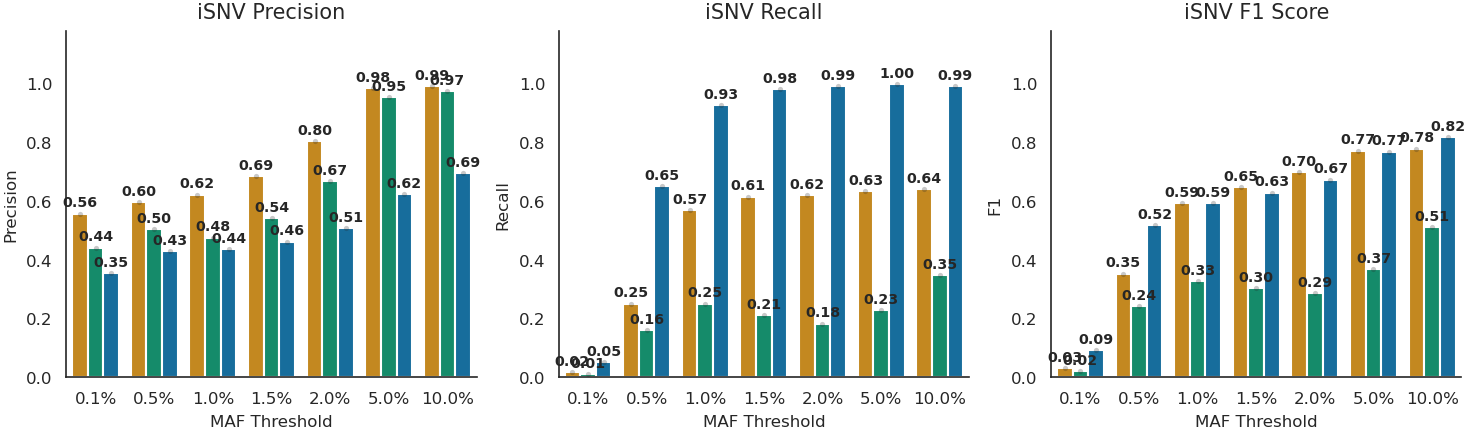

In [ ]:
fig, ax = plt.subplots(1,3, figsize=(12, 3), sharex=True)
plot_precision_recall_f1(pooled_counts, ax, kind='bar', show_dots=True)

The same counts one row per dataset folder, in case a threshold's totals need to be traced
back to which simulation produced them.

In [ ]:
folder_counts = counts_by_dataset(mr1e_minors)

# one wide table per folder, stacked
per_folder_wide = pd.concat(
    {ds: count_table_wide(b) for ds, b in folder_counts.groupby('unit')},
    names=['dataset'])
per_folder_wide.reset_index()[['MAF', 'n_samples_truth']].value_counts().sort_index()

MAF    n_samples_truth
0.001  9                   2
       10                 78
0.005  2                   1
       5                   2
       6                   5
                          ..
0.100  6                   3
       7                  10
       8                   4
       9                   4
       10                  9
Name: count, Length: 61, dtype: int64

## Strand bias by truth status

The same treatment as `simulated_ebola_runs/ebola_rsv_figure.ipynb`, but the truth here
arrives differently and that changes two things.

**Where truth status comes from.** There is no `af_accuracy.tsv`. `load_dataset()` above
already merges each sample's calls against
`TRUTH_ROOT/<dataset>/<sample>/HPV16REF_inserted_mutations_overview.csv`, leaving a
`truth` flag and a `tools` column naming the callers that found each site. Status is
therefore derived per tool from those two columns: called and true is TP, called and not
true is FP, true and not called by *this* tool is FN. Sites that are neither called nor
true are dropped. Primer-covered positions are already gone -- `load_dataset()` masks
them from calls and truth alike.

**Strand counts come from the shared bowtie2 pileup, not from each caller.** For ebola
and RSV-A the metrics had to be rebuilt per caller from its own output. Here
`minor_variants.tsv` already carries per-strand base counts (`A_bt2` forward, `a_bt2`
reverse) from one pileup common to all three tools -- the same measurement `alt_maf` is
taken from -- so SOR / STR_BAL / REF_BAL / ALT_BAL are computed once and every tool sits
on that one axis. The formulas are still bronko's own (`src/call.rs:1434`, `:1861`).

This has a consequence worth stating plainly: **missed variants are measurable here.**
A truth variant nobody called has no row in `minor_variants.tsv`, but the position is
still in that sample's `bt_results.tsv` pileup, so `backfill_truth_strand_counts()`
recovers its counts. In the ebola/rsva notebook FN had to go in a separate panel because
no record of it existed at all; here FN can be drawn on the same axes as TP and FP.

**FN dominates and is scoped accordingly.** Most simulated truth variants sit below
`MIN_AF` and no tool can reach them, so unscoped FN outnumbers TP and FP by roughly fifty
to one. `SCOPE_MAF` restricts the figures to the same variants panel A's lowest threshold
uses (`alt_maf > MIN_AF`); FN is still drawn faint underneath TP and FP so its shape is
visible without burying them.

In [15]:
SCOPE_MAF = MIN_AF      # match panel A's lowest MAF threshold; raise to zoom in

STATUS_COLORS = {'TP': '#4C9F70', 'FP': '#C4453C', 'FN': '#9AA0A6'}
CALLER_LABEL = {'bronko': 'bronko', 'lofreq': 'LoFreq', 'ivar': 'iVar'}
BT2_COLS = [f'{b}_bt2' for b in BASES] + [f'{b.lower()}_bt2' for b in BASES]


def backfill_truth_strand_counts(minor, run_root=RUN_ROOT):
    """Fill in bt2 strand counts for truth rows that no tool called.

    A called row already carries its counts from minor_variants.tsv. A truth variant
    nobody called exists only as the right half of the outer merge in load_dataset(), so
    its count columns are NaN -- but the position is still in that sample's bowtie2
    pileup, so they can be recovered from bt_results.tsv. This is what lets HPV place
    missed variants on the strand-bias axes at all.
    """
    need = minor[minor[BT2_COLS[0]].isna()]
    if need.empty:
        return minor

    filled = []
    for (dataset, run), grp in need.groupby(['dataset', 'run'], sort=False):
        pile_path = Path(run_root) / dataset / run / 'rep1_R1_k21' / 'bt_results.tsv'
        if not pile_path.exists():
            continue
        pile = pd.read_csv(pile_path, sep='\t').set_index('index')
        pos = pd.to_numeric(grp['position'], errors='coerce')
        hit = pos[pos.isin(pile.index)]
        if hit.empty:
            continue
        sub = pile.loc[hit.values]
        block = pd.DataFrame(
            {f'{b}_bt2': sub[b].values for b in BASES} |
            {f'{b.lower()}_bt2': sub[b.lower()].values for b in BASES},
            index=hit.index)
        block['ref'] = sub['ref'].values
        filled.append(block)

    if not filled:
        return minor
    filled = pd.concat(filled)
    minor = minor.copy()
    for col in filled.columns:
        minor.loc[filled.index, col] = filled[col]
    return minor


def add_strand_metrics(minor):
    """bronko's SOR / STR_BAL / REF_BAL / ALT_BAL from the shared bowtie2 strand counts.

    Formulas are bronko's own (src/call.rs:1434 strand_balance, :1861 strand_odds_ratio),
    including its +1 pseudocount, but the counts are the bowtie2 pileup rather than any
    one caller's, so all three tools are measured the same way.
    """
    m = minor.copy()
    # truth-only rows carry the alt in `Variant`; called rows carry it in `alt`
    alt = m['alt'].where(m['alt'].notna(), m['Variant']) if 'Variant' in m else m['alt']
    ref = m['ref']
    ok = alt.notna() & ref.notna() & m[BT2_COLS[0]].notna()

    def strand_count(base_series, forward):
        out = pd.Series(np.nan, index=m.index, dtype=float)
        for b in BASES:
            col = f'{b}_bt2' if forward else f'{b.lower()}_bt2'
            sel = ok & (base_series.astype(str).str.upper() == b)
            out.loc[sel] = pd.to_numeric(m.loc[sel, col], errors='coerce')
        return out

    rf, rr = strand_count(ref, True), strand_count(ref, False)
    af, ar = strand_count(alt, True), strand_count(alt, False)

    a, b_, c, d = rf + 1.0, rr + 1.0, af + 1.0, ar + 1.0
    r = (a * d) / (b_ * c)
    m['SOR'] = (np.log(r + 1.0 / r)
                + np.log(np.minimum(a, b_) / np.maximum(a, b_))
                - np.log(np.minimum(c, d) / np.maximum(c, d)))
    m['STR_BAL'] = np.minimum(a + c, b_ + d) / (a + b_ + c + d)
    m['REF_BAL'] = np.minimum(a, b_) / (a + b_)
    m['ALT_BAL'] = np.minimum(c, d) / (c + d)
    m['DP_bt2'] = rf + rr + af + ar
    m['pos'] = pd.to_numeric(
        m['index'].where(m['index'].notna(), m['position']) if 'position' in m
        else m['index'], errors='coerce')
    m['mutation'] = ref.astype(str).str.upper() + '>' + alt.astype(str).str.upper()
    return m


def expand_by_tool(minor, tool_order=TOOL_ORDER):
    """One row per (variant, tool), labelled TP / FP / FN from `tools` and `truth`.

    FN includes truth variants another tool did call, so most FN rows still have measured
    strand counts. True negatives (not called, not truth) are dropped.
    """
    tools = minor['tools'].fillna('').astype(str).str.split(',')
    out = []
    for tool in tool_order:
        called = tools.apply(lambda ts: tool in ts)
        truth = minor['truth'] == 1
        status = pd.Series(pd.NA, index=minor.index, dtype='object')
        status[called & truth] = 'TP'
        status[called & ~truth] = 'FP'
        status[~called & truth] = 'FN'
        keep = status.notna()
        d = minor[keep].copy()
        d['caller'] = tool
        d['status'] = status[keep]
        out.append(d)
    return pd.concat(out, ignore_index=True)


def prepare_strand_table(minors_dict, scope_maf=None):
    """{dataset: minor_all} -> tidy frame with strand metrics and per-tool truth status."""
    allm = pd.concat(minors_dict.values(), ignore_index=True)
    allm = backfill_truth_strand_counts(allm)
    allm = add_strand_metrics(allm)
    tidy = expand_by_tool(allm)
    scope = SCOPE_MAF if scope_maf is None else scope_maf
    return tidy[tidy['alt_maf'] > scope] if scope else tidy


strand_tidy = prepare_strand_table(mr1e_minors)
print(f'{len(strand_tidy):,} (variant, tool) rows above MAF {SCOPE_MAF}')
print(strand_tidy.groupby(['caller', 'status']).size().unstack(fill_value=0).to_string())
print('\nmedian metric per status -- how far apart are TP and FP?')
print(strand_tidy[strand_tidy['status'].isin(['TP', 'FP'])]
      .groupby(['caller', 'status'])[['SOR', 'STR_BAL', 'REF_BAL', 'ALT_BAL']]
      .median().round(3).to_string())

1,243,765 (variant, tool) rows above MAF 0.001
status      FN     FP     TP
caller                      
bronko  391804   6562   5605
ivar    375858  39533  21551
lofreq  393069   5443   4340

median metric per status -- how far apart are TP and FP?
                 SOR  STR_BAL  REF_BAL  ALT_BAL
caller status                                  
bronko FP      1.203    0.136    0.135    0.057
       TP      3.103    0.168    0.168    0.036
ivar   FP      4.019    0.287    0.287    0.051
       TP      4.265    0.314    0.314    0.043
lofreq FP      0.842    0.074    0.075    0.038
       TP      1.506    0.130    0.129    0.064


In [16]:
def _draw_by_status(ax, d, x, y, show_fn=True):
    """FN first and faint: it outnumbers TP and FP by roughly fifty to one even after the
    MAF scope, so it reads as background texture instead of burying the other two."""
    if show_fn:
        sub = d[d['status'] == 'FN'].dropna(subset=[x, y])
        if len(sub):
            ax.scatter(sub[x], sub[y], s=3, alpha=0.12, linewidth=0,
                       color=STATUS_COLORS['FN'], label=f'FN (n={len(sub):,})')
    for st in ('FP', 'TP'):
        sub = d[d['status'] == st].dropna(subset=[x, y])
        if len(sub):
            ax.scatter(sub[x], sub[y], s=7, alpha=0.5, linewidth=0,
                       color=STATUS_COLORS[st], label=f'{st} (n={len(sub):,})')
    ax.grid(alpha=0.15, linewidth=0.5)


def fig_strand_metrics(tidy, title):
    """Metric pairs per caller, TP / FP over the FN background."""
    pairs = [('SOR', 'STR_BAL'), ('alt_maf', 'STR_BAL'),
             ('alt_maf', 'SOR'), ('REF_BAL', 'ALT_BAL')]
    fig, axes = plt.subplots(len(TOOL_ORDER), len(pairs), figsize=(13, 8.5))
    for i, caller in enumerate(TOOL_ORDER):
        d = tidy[tidy['caller'] == caller]
        for j, (x, y) in enumerate(pairs):
            ax = axes[i, j]
            _draw_by_status(ax, d, x, y)
            ax.set_xlabel('MAF (bowtie2)' if x == 'alt_maf' else x, fontsize=8)
            ax.set_ylabel(y if j == 0 else '', fontsize=8)
            if y in ('STR_BAL', 'REF_BAL', 'ALT_BAL'):
                ax.set_ylim(-0.02, 0.52)
            if x == 'alt_maf':
                ax.set_xscale('log')
            if i == 0:
                ax.set_title(f'{"MAF" if x == "alt_maf" else x} vs {y}', fontsize=9)
            if j == 0:
                ax.text(-0.32, 0.5, CALLER_LABEL[caller], transform=ax.transAxes,
                        fontsize=11, fontweight='bold', rotation=90,
                        ha='center', va='center')
            ax.legend(fontsize=6, loc='best', framealpha=0.85, markerscale=2.5)
    fig.suptitle(title, fontsize=13, fontweight='bold')
    fig.tight_layout(rect=(0.02, 0, 1, 0.96))
    return fig


def fig_strand_genome(tidy, title):
    """MAF and strand balance along the HPV16 genome, per caller."""
    fig, axes = plt.subplots(len(TOOL_ORDER), 2, figsize=(13, 8), sharex=True)
    for i, caller in enumerate(TOOL_ORDER):
        d = tidy[tidy['caller'] == caller]
        for j, y in enumerate(['alt_maf', 'STR_BAL']):
            ax = axes[i, j]
            _draw_by_status(ax, d, 'pos', y)
            ax.set_ylabel('MAF (bowtie2)' if y == 'alt_maf' else y, fontsize=8)
            if y == 'STR_BAL':
                ax.set_ylim(-0.02, 0.52)
            else:
                ax.set_yscale('log')
            if i == len(TOOL_ORDER) - 1:
                ax.set_xlabel('HPV16 genome position', fontsize=9)
            if i == 0:
                ax.set_title(('MAF' if y == 'alt_maf' else y) + ' across the genome',
                             fontsize=9)
            if j == 0:
                ax.text(-0.10, 0.5, CALLER_LABEL[caller], transform=ax.transAxes,
                        fontsize=11, fontweight='bold', rotation=90,
                        ha='center', va='center')
            ax.legend(fontsize=6, loc='upper right', framealpha=0.85, markerscale=2.5)
    fig.suptitle(title, fontsize=13, fontweight='bold')
    fig.tight_layout(rect=(0.02, 0, 1, 0.96))
    return fig


def fig_tp_fp_separation(tidy, title):
    """Does any metric actually separate TP from FP? A violin pair per caller per metric.

    Worth reading before treating any of these as a filter: overlapping violins mean a
    cut on that metric cannot remove false positives without taking true ones with it.
    """
    metrics = ['SOR', 'STR_BAL', 'REF_BAL', 'ALT_BAL']
    fig, axes = plt.subplots(1, len(metrics), figsize=(13, 3.4))
    for ax, metric in zip(axes, metrics):
        data, labels, colors = [], [], []
        for caller in TOOL_ORDER:
            for st in ('TP', 'FP'):
                v = tidy[(tidy['caller'] == caller) & (tidy['status'] == st)][metric].dropna()
                if len(v):
                    data.append(v.values)
                    labels.append(f'{CALLER_LABEL[caller][:3]}\n{st}')
                    colors.append(STATUS_COLORS[st])
        if not data:
            continue
        parts = ax.violinplot(data, showmedians=True, widths=0.85)
        for body, col in zip(parts['bodies'], colors):
            body.set_facecolor(col)
            body.set_alpha(0.65)
        for key in ('cbars', 'cmins', 'cmaxes', 'cmedians'):
            if key in parts:
                parts[key].set_color('0.25')
                parts[key].set_linewidth(0.9)
        ax.set_xticks(range(1, len(labels) + 1))
        ax.set_xticklabels(labels, fontsize=6.5)
        ax.set_title(metric, fontsize=10)
        ax.grid(alpha=0.15, linewidth=0.5, axis='y')
    fig.suptitle(title, fontsize=12, fontweight='bold')
    fig.tight_layout(rect=(0, 0, 1, 0.90))
    return fig


def fig_missed(tidy, title):
    """Where the missed truth variants sit in MAF, and the recall that implies."""
    fn = tidy[tidy['status'] == 'FN']
    fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))

    ax = axes[0]
    lo = max(fn['alt_maf'].replace(0, np.nan).min(), 1e-5)
    bins = np.logspace(np.log10(lo), np.log10(max(fn['alt_maf'].max(), lo * 10)), 45)
    for caller in TOOL_ORDER:
        v = fn[fn['caller'] == caller]['alt_maf'].dropna()
        ax.hist(v, bins=bins, histtype='step', linewidth=1.6,
                color=TOOL_PALETTE[caller], label=f'{CALLER_LABEL[caller]} (n={len(v):,})')
    ax.set_xscale('log')
    ax.set_xlabel('MAF (bowtie2)', fontsize=9)
    ax.set_ylabel('missed count', fontsize=9)
    ax.set_title('MAF of missed truth variants', fontsize=10)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.15, linewidth=0.5, axis='y')

    ax = axes[1]
    for caller in TOOL_ORDER:
        d = tidy[tidy['caller'] == caller]
        grid = np.logspace(np.log10(max(d['alt_maf'].replace(0, np.nan).min(), 1e-5)),
                           np.log10(d['alt_maf'].max()), 40)
        rec = [((d['status'].eq('TP') & d['alt_maf'].gt(t)).sum()
                / max((d['status'].isin(['TP', 'FN']) & d['alt_maf'].gt(t)).sum(), 1))
               for t in grid]
        ax.plot(grid, rec, linewidth=1.6, color=TOOL_PALETTE[caller],
                label=CALLER_LABEL[caller])
    ax.set_xscale('log')
    ax.set_xlabel('MAF threshold', fontsize=9)
    ax.set_ylabel('recall above threshold', fontsize=9)
    ax.set_ylim(-0.02, 1.02)
    ax.set_title('Recall as a function of MAF', fontsize=10)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.15, linewidth=0.5)

    fig.suptitle(title, fontsize=12, fontweight='bold')
    fig.tight_layout(rect=(0, 0, 1, 0.90))
    return fig

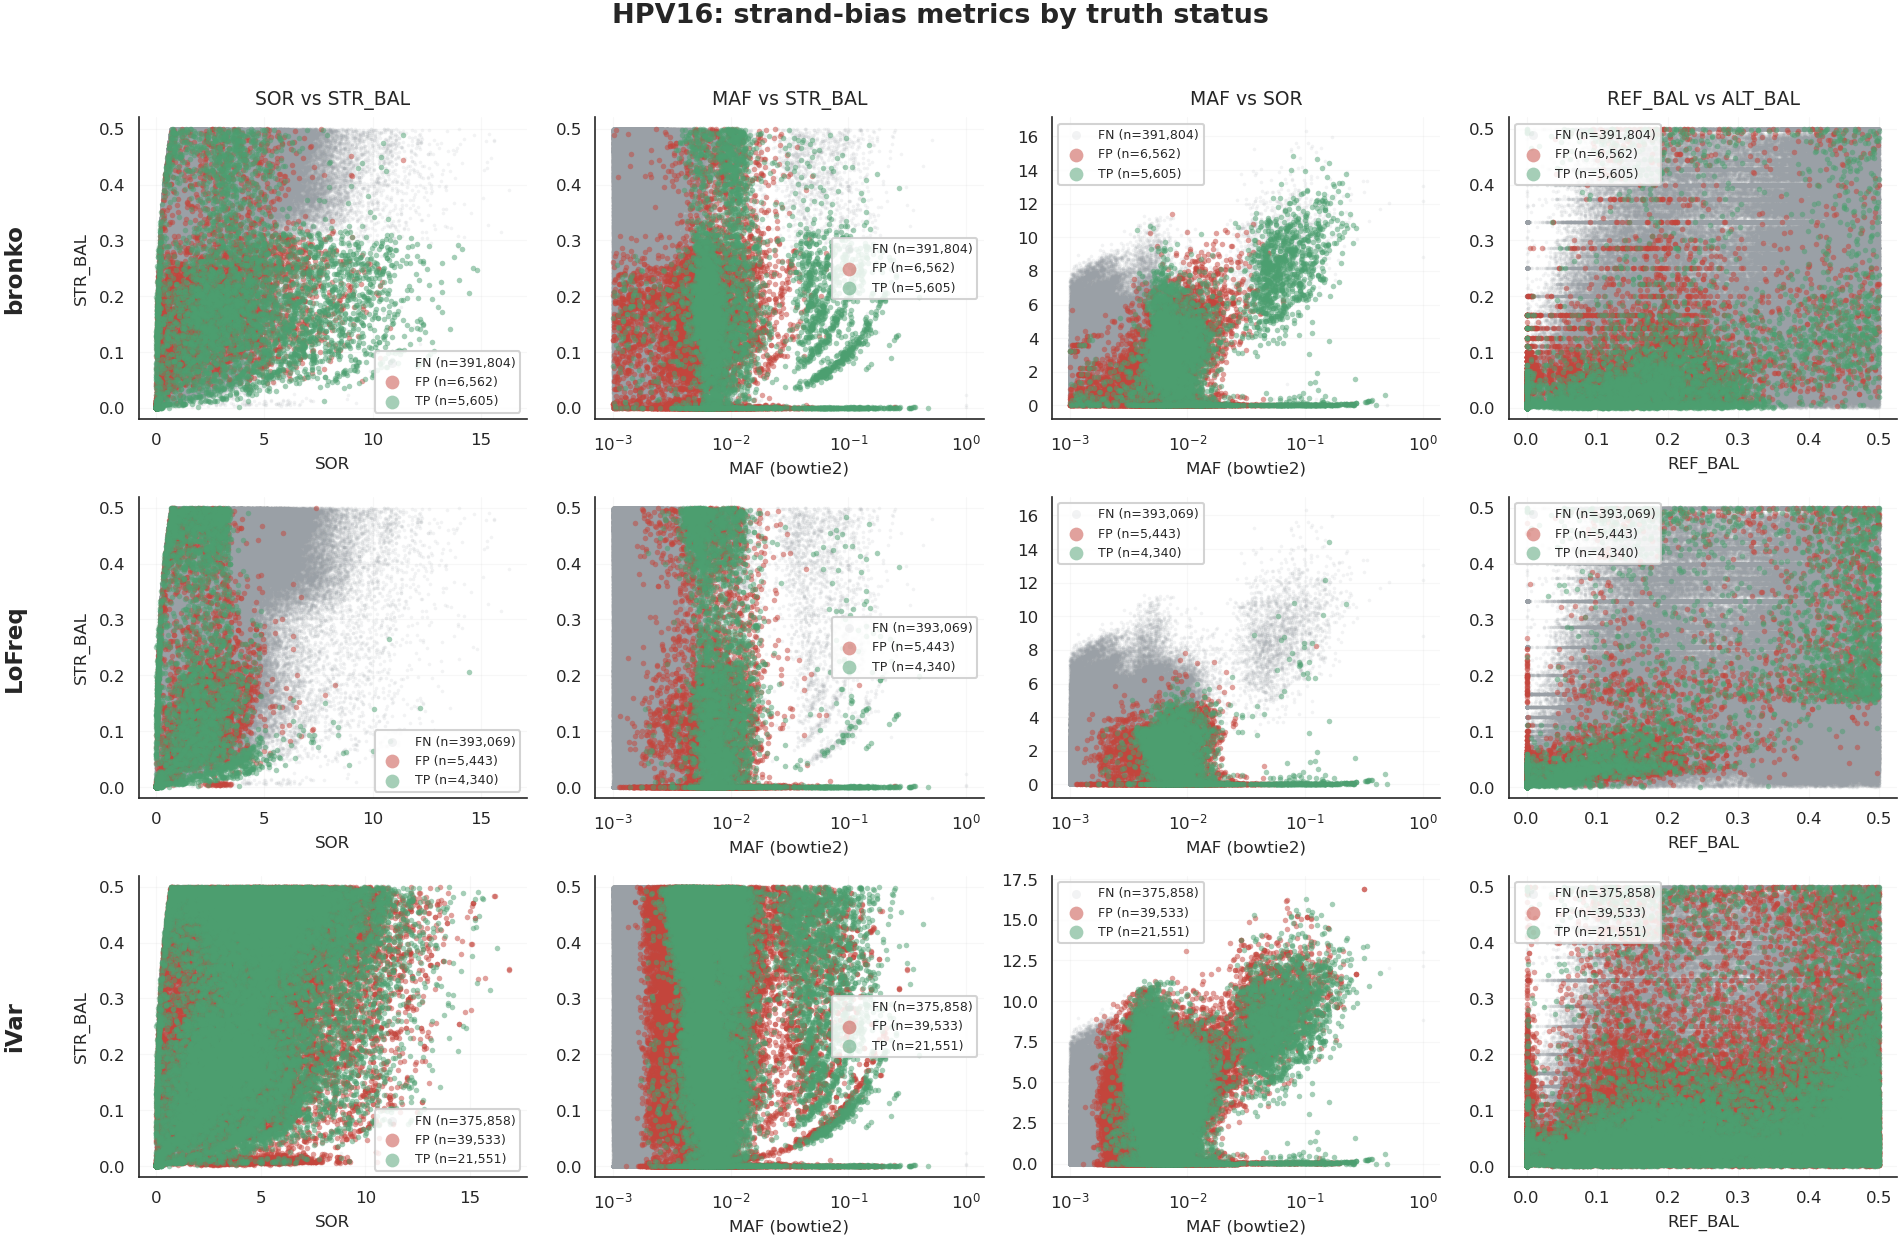

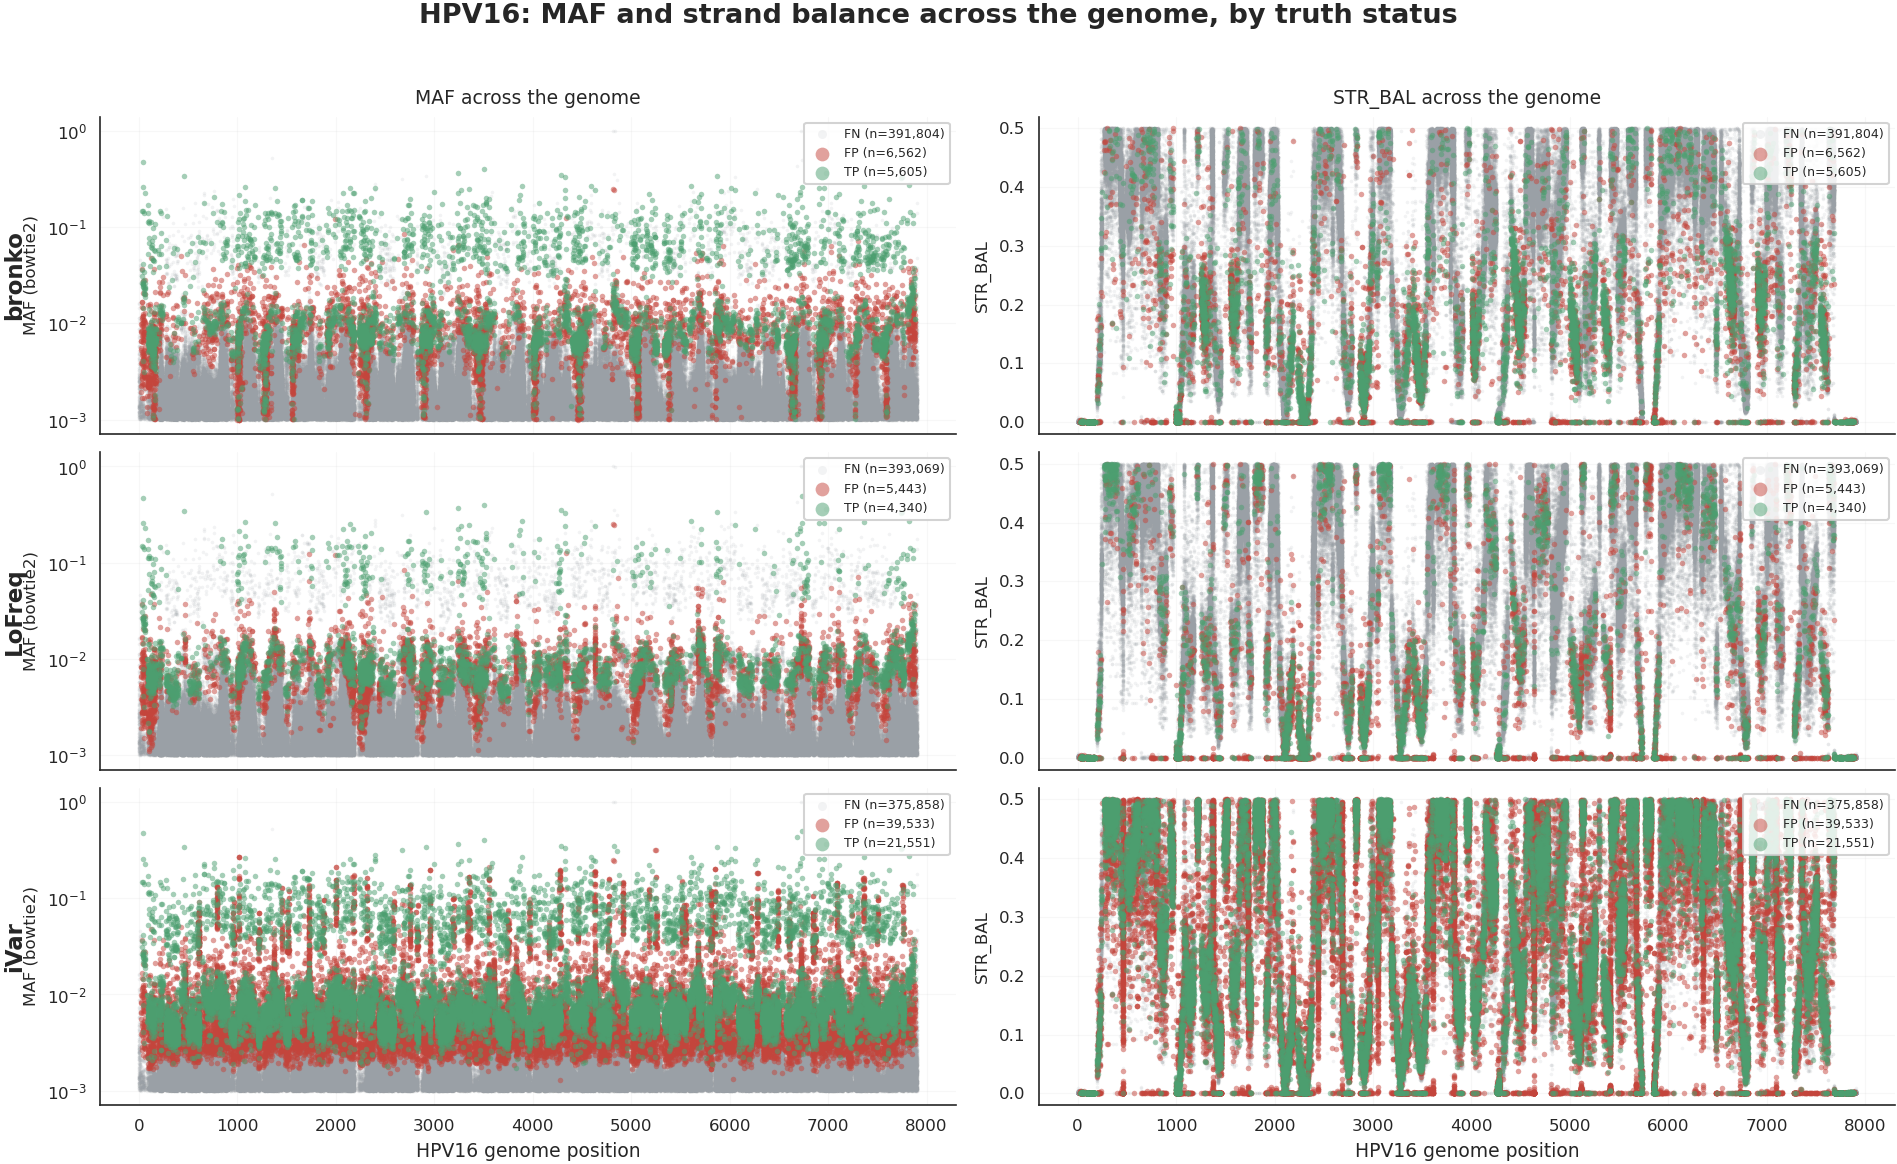

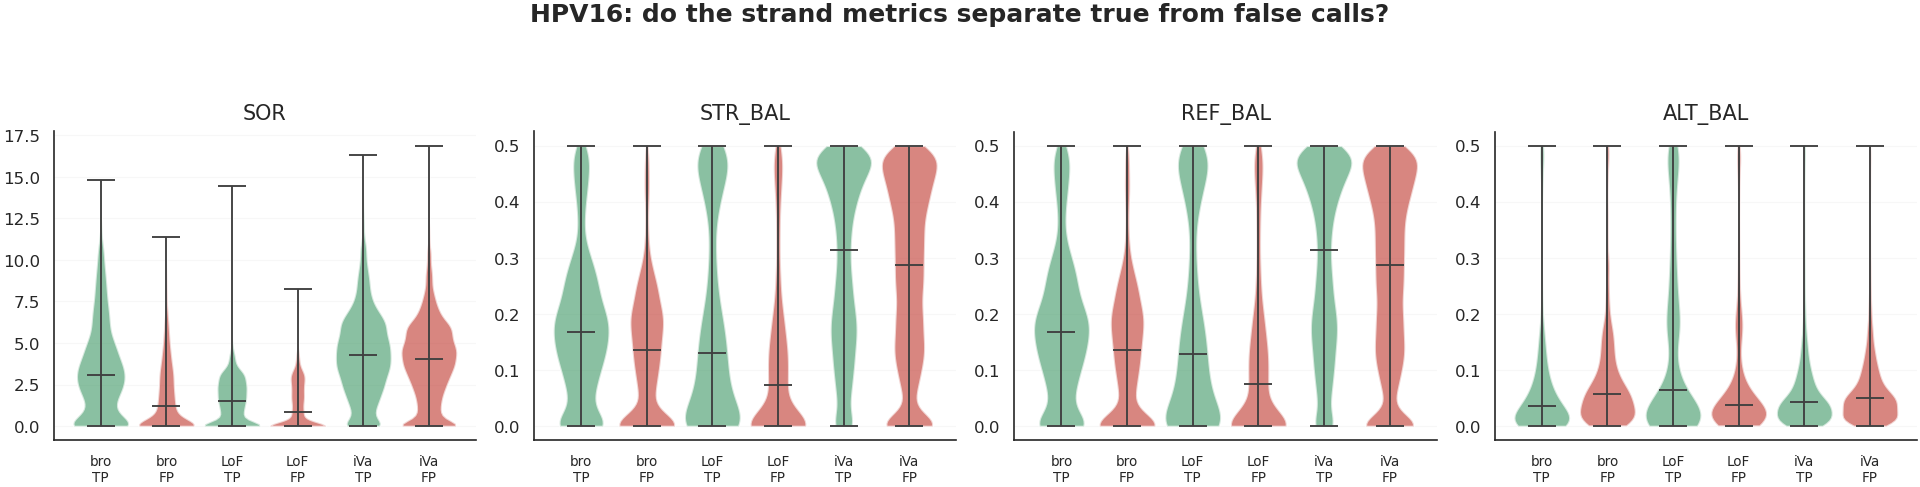

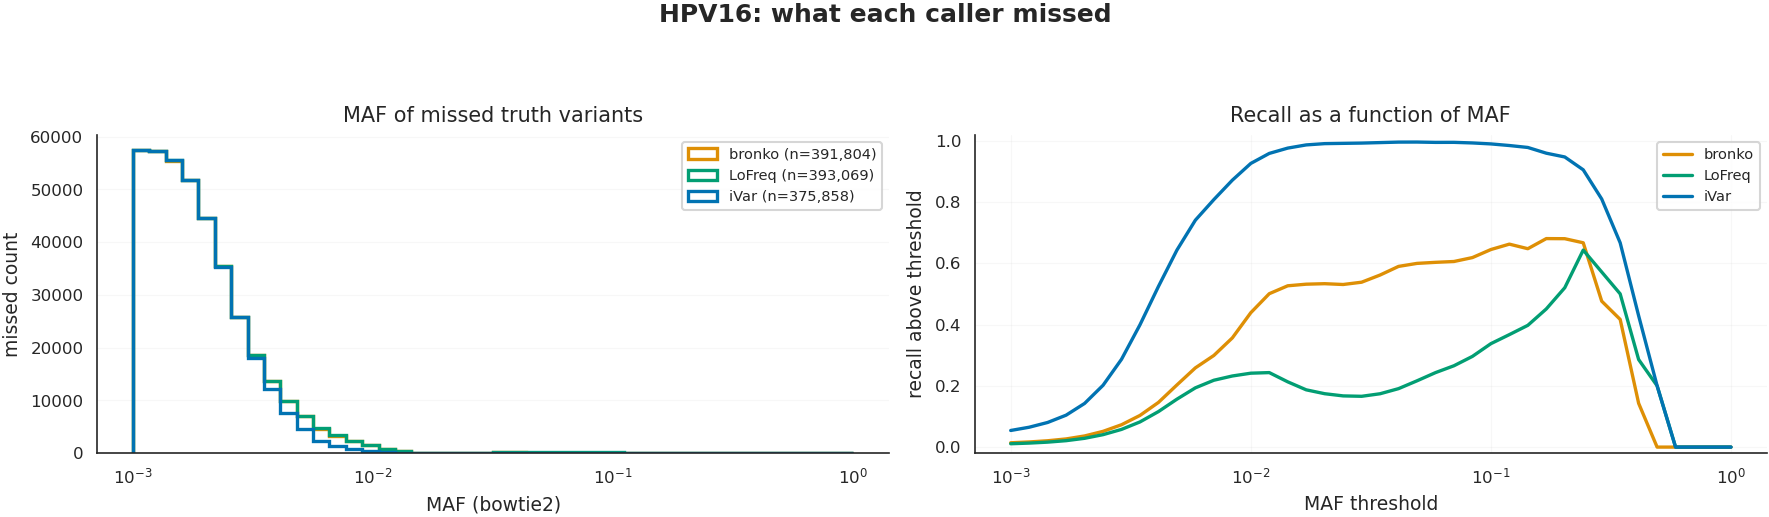

In [17]:
strand_figs = {
    'HPV_strandbias_metrics': fig_strand_metrics(
        strand_tidy, 'HPV16: strand-bias metrics by truth status'),
    'HPV_strandbias_genome': fig_strand_genome(
        strand_tidy, 'HPV16: MAF and strand balance across the genome, by truth status'),
    'HPV_strandbias_separation': fig_tp_fp_separation(
        strand_tidy, 'HPV16: do the strand metrics separate true from false calls?'),
    'HPV_missed_variants': fig_missed(
        strand_tidy, 'HPV16: what each caller missed'),
}
plt.show()

In [18]:
for name, fig in strand_figs.items():
    for ext in ('png', 'pdf'):
        fig.savefig(f'../figures/{name}.{ext}', bbox_inches='tight', dpi=600,
                    facecolor='white')
    print('saved', name)

saved HPV_strandbias_metrics
saved HPV_strandbias_genome
saved HPV_strandbias_separation
saved HPV_missed_variants
